# NB05: Environmental Distribution of AMR Genes

**Goal**: Test H4 — do species from different environments carry different AMR profiles? Use NCBI environment metadata and AlphaEarth embeddings.

**Caveats**: 
- `ncbi_env` is EAV-format (key-value), sparse and inconsistent
- AlphaEarth embeddings cover only 28% of genomes
- Strong clinical/pathogen sampling bias in genome databases

**Depends on**: NB01 outputs + Spark session

**Outputs**:
- `../data/amr_by_environment.csv`
- `../figures/amr_environment_*.png`

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

try:
    spark = get_spark_session()
except NameError:
    sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..', 'scripts'))
    from get_spark_session import get_spark_session
    spark = get_spark_session()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
})

amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
species = pd.read_csv(DATA_DIR / 'amr_species_summary.csv')
print(f"Loaded {len(amr):,} AMR clusters, {len(species):,} species")

Loaded 83,008 AMR clusters, 14,723 species


## 1. Environment Classification from NCBI Metadata

Extract isolation_source from `ncbi_env` and classify into broad environment categories. This is EAV-format data — we need to pivot and harmonize.

In [2]:
# Get isolation_source for genomes in AMR-carrying species
# ncbi_env: accession (BioSample ID), attribute_name, content
# genome table has ncbi_biosample_id — join directly, skip sample table

env_data = spark.sql("""
    SELECT g.gtdb_species_clade_id, g.ncbi_biosample_id, e.content as isolation_source
    FROM kbase_ke_pangenome.genome g
    JOIN kbase_ke_pangenome.ncbi_env e ON g.ncbi_biosample_id = e.accession
    WHERE e.attribute_name = 'isolation_source'
""").toPandas()

print(f"Isolation source records: {len(env_data):,}")
print(f"Genomes with isolation_source: {env_data['ncbi_biosample_id'].nunique():,}")
print(f"Species with isolation_source: {env_data['gtdb_species_clade_id'].nunique():,}")
print(f"\nTop 20 isolation sources:")
print(env_data['isolation_source'].value_counts().head(20).to_string())

Isolation source records: 163,752
Genomes with isolation_source: 163,568
Species with isolation_source: 21,893

Top 20 isolation sources:
isolation_source
missing                            14093
feces                               8875
blood                               6877
sputum                              5217
stool                               4617
soil                                3996
ruminant gastrointestinal tract     2807
urine                               2632
patient                             1785
hypoxic seawater                    1665
not collected                       1653
groundwater                         1631
human gut                           1510
fecal sample                        1331
Unknown                             1294
not applicable                      1222
stool sample                        1190
food                                1107
permafrost active layer soil        1095
chicken caecal content              1016


In [3]:
# Classify isolation_source into broad categories
def classify_environment(source):
    """Classify isolation_source text into broad categories."""
    if pd.isna(source):
        return 'Unknown'
    s = str(source).lower()
    
    # Clinical/Human
    if any(k in s for k in ['blood', 'sputum', 'urine', 'wound', 'clinical', 'patient',
                             'hospital', 'abscess', 'csf', 'biopsy', 'stool', 'feces',
                             'human', 'homo sapiens', 'nasopharyn', 'throat', 'skin',
                             'respiratory', 'lung', 'rectal', 'vaginal', 'urinary']):
        return 'Human/Clinical'
    
    # Animal host
    if any(k in s for k in ['chicken', 'cattle', 'pig', 'swine', 'bovine', 'poultry',
                             'dog', 'cat', 'fish', 'mouse', 'rat', 'animal', 'veterinary',
                             'insect', 'tick', 'mosquito', 'bird']):
        return 'Animal'
    
    # Food
    if any(k in s for k in ['food', 'milk', 'cheese', 'meat', 'ferment', 'yogurt',
                             'kimchi', 'sausage', 'vegetable', 'fruit', 'grain']):
        return 'Food'
    
    # Soil/Terrestrial
    if any(k in s for k in ['soil', 'rhizosphere', 'root', 'sediment', 'mud', 'compost',
                             'agricultural', 'farm', 'forest', 'grassland']):
        return 'Soil/Terrestrial'
    
    # Aquatic
    if any(k in s for k in ['water', 'river', 'lake', 'ocean', 'sea', 'marine', 'aquatic',
                             'wastewater', 'sewage', 'freshwater', 'groundwater']):
        return 'Aquatic'
    
    # Plant
    if any(k in s for k in ['plant', 'leaf', 'stem', 'flower', 'seed', 'phyllosphere']):
        return 'Plant'
    
    return 'Other/Unknown'

# Apply classification directly — env_data already has isolation_source column
env_data['env_category'] = env_data['isolation_source'].apply(classify_environment)

# Species-level: majority environment classification
species_env = env_data.groupby('gtdb_species_clade_id')['env_category'].agg(
    lambda x: x.value_counts().index[0]  # mode
).reset_index()
species_env.columns = ['gtdb_species_clade_id', 'primary_env']

print(f"=== Environment Classification ===")
print(env_data['env_category'].value_counts().to_string())
print(f"\nSpecies with environment classification: {len(species_env):,}")

=== Environment Classification ===
env_category
Other/Unknown       63938
Human/Clinical      50332
Aquatic             19054
Soil/Terrestrial    15098
Animal               8308
Food                 5231
Plant                1791

Species with environment classification: 21,893


Species with AMR + environment: 7,838

=== AMR by Environment ===
                  n_species  mean_amr  median_amr  total_amr  mean_core_pct
primary_env                                                                
Human/Clinical         2248     10.59         4.0      23798          30.81
Food                    182      9.01         4.0       1639          38.01
Plant                   153      4.71         3.0        721          63.09
Soil/Terrestrial       2469      4.63         3.0      11427          58.05
Aquatic                1827      3.87         2.0       7064          48.88
Animal                  959      3.03         2.0       2908          40.23

Kruskal-Wallis (AMR count ~ environment): H=440.0, p=6.98e-93


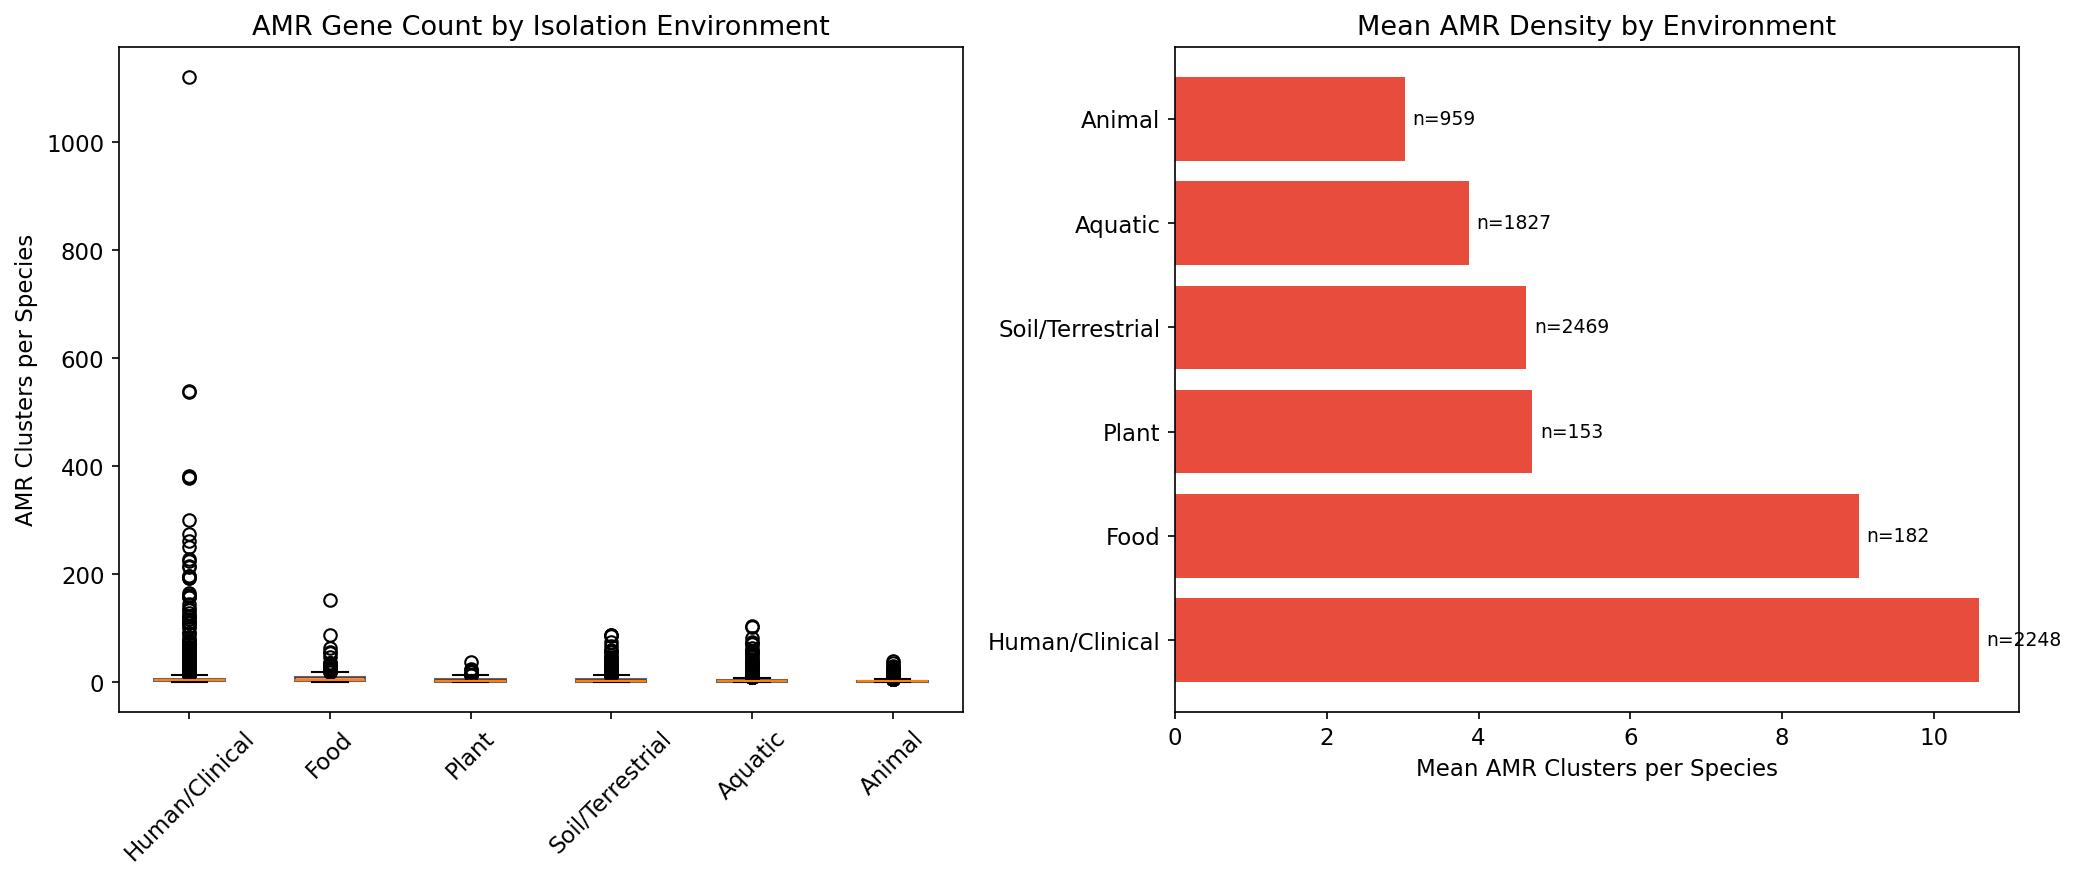


Saved to data/amr_by_environment.csv


In [4]:
# Merge environment with species AMR data
species_with_env = species.merge(species_env, on='gtdb_species_clade_id', how='inner')
species_with_env = species_with_env[species_with_env['primary_env'] != 'Other/Unknown']

print(f"Species with AMR + environment: {len(species_with_env):,}")
print(f"\n=== AMR by Environment ===")

env_amr = species_with_env.groupby('primary_env').agg(
    n_species=('gtdb_species_clade_id', 'count'),
    mean_amr=('n_amr', 'mean'),
    median_amr=('n_amr', 'median'),
    total_amr=('n_amr', 'sum'),
    mean_core_pct=('pct_core_amr', 'mean')
).round(2).sort_values('mean_amr', ascending=False)

print(env_amr.to_string())

# Kruskal-Wallis test: does AMR count differ by environment?
groups = [g['n_amr'].values for _, g in species_with_env.groupby('primary_env')]
h_stat, p_kw = stats.kruskal(*[g for g in groups if len(g) >= 5])
print(f"\nKruskal-Wallis (AMR count ~ environment): H={h_stat:.1f}, p={p_kw:.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot: AMR count by environment
env_order = env_amr.index.tolist()
bp_data = [species_with_env[species_with_env['primary_env'] == e]['n_amr'].values for e in env_order]
bp = axes[0].boxplot(bp_data, labels=env_order, vert=True, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#e74c3c')
    patch.set_alpha(0.6)
axes[0].set_ylabel('AMR Clusters per Species')
axes[0].set_title('AMR Gene Count by Isolation Environment')
axes[0].tick_params(axis='x', rotation=45)

# Bar: mean AMR by environment
axes[1].barh(env_amr.index, env_amr['mean_amr'], color='#e74c3c')
axes[1].set_xlabel('Mean AMR Clusters per Species')
axes[1].set_title('Mean AMR Density by Environment')
for i, (idx, row) in enumerate(env_amr.iterrows()):
    axes[1].text(row['mean_amr'] + 0.1, i, f'n={int(row["n_species"])}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_by_environment.png')
plt.show()

species_with_env.to_csv(DATA_DIR / 'amr_by_environment.csv', index=False)
print(f"\nSaved to data/amr_by_environment.csv")

## 2. AlphaEarth Embeddings Analysis

AlphaEarth provides 64-dimensional environmental embeddings for 83K genomes (28% coverage). These encode environmental context learned from geospatial data. Questions:
- Do AMR-rich species have different environmental embeddings?
- Does environmental diversity (embedding spread) correlate with AMR count?

In [5]:
# Load AlphaEarth embeddings — 83K rows but wide (64+ columns)
# Fetch in two steps to avoid gRPC message size limit:
# 1) Get genome_id → species mapping for AE genomes
# 2) Get embeddings separately

# Step 1: Which genomes have embeddings + their species
ae_genomes = spark.sql("""
    SELECT ae.genome_id, g.gtdb_species_clade_id
    FROM kbase_ke_pangenome.alphaearth_embeddings_all_years ae
    JOIN kbase_ke_pangenome.genome g ON ae.genome_id = g.genome_id
""").toPandas()
print(f"AlphaEarth genomes: {len(ae_genomes):,}")
print(f"Species with embeddings: {ae_genomes['gtdb_species_clade_id'].nunique():,}")

# Step 2: Get embedding columns (fetch in chunks by genome_id to stay under gRPC limit)
# First discover column names
ae_schema = spark.sql("DESCRIBE kbase_ke_pangenome.alphaearth_embeddings_all_years").toPandas()
emb_cols = [r['col_name'] for _, r in ae_schema.iterrows() 
            if r['col_name'] != 'genome_id' and r['data_type'] in ('double', 'float')]
print(f"Embedding dimensions: {len(emb_cols)}")

# Fetch embeddings in chunks of 5000 genomes
all_emb_ids = ae_genomes['genome_id'].tolist()
emb_chunks = []
for i in range(0, len(all_emb_ids), 5000):
    chunk = all_emb_ids[i:i+5000]
    id_list = "','".join(chunk)
    cols = ', '.join(emb_cols)
    df = spark.sql(f"SELECT genome_id, {cols} FROM kbase_ke_pangenome.alphaearth_embeddings_all_years WHERE genome_id IN ('{id_list}')").toPandas()
    emb_chunks.append(df)
ae_emb = pd.concat(emb_chunks, ignore_index=True)

# Merge
ae = ae_genomes.merge(ae_emb, on='genome_id', how='inner')
print(f"Loaded embeddings for {len(ae):,} genomes")

AlphaEarth genomes: 83,287
Species with embeddings: 15,046


Embedding dimensions: 66


Loaded embeddings for 83,617 genomes


Species with >= 3 genomes and embeddings: 4,949


Species with environmental diversity scores: 4,528
AMR species with environmental diversity: 2,684

Spearman correlation (env diversity vs AMR count): rho=0.466, p=1.56e-144
Spearman correlation (env diversity vs % core AMR): rho=-0.173, p=1.83e-19


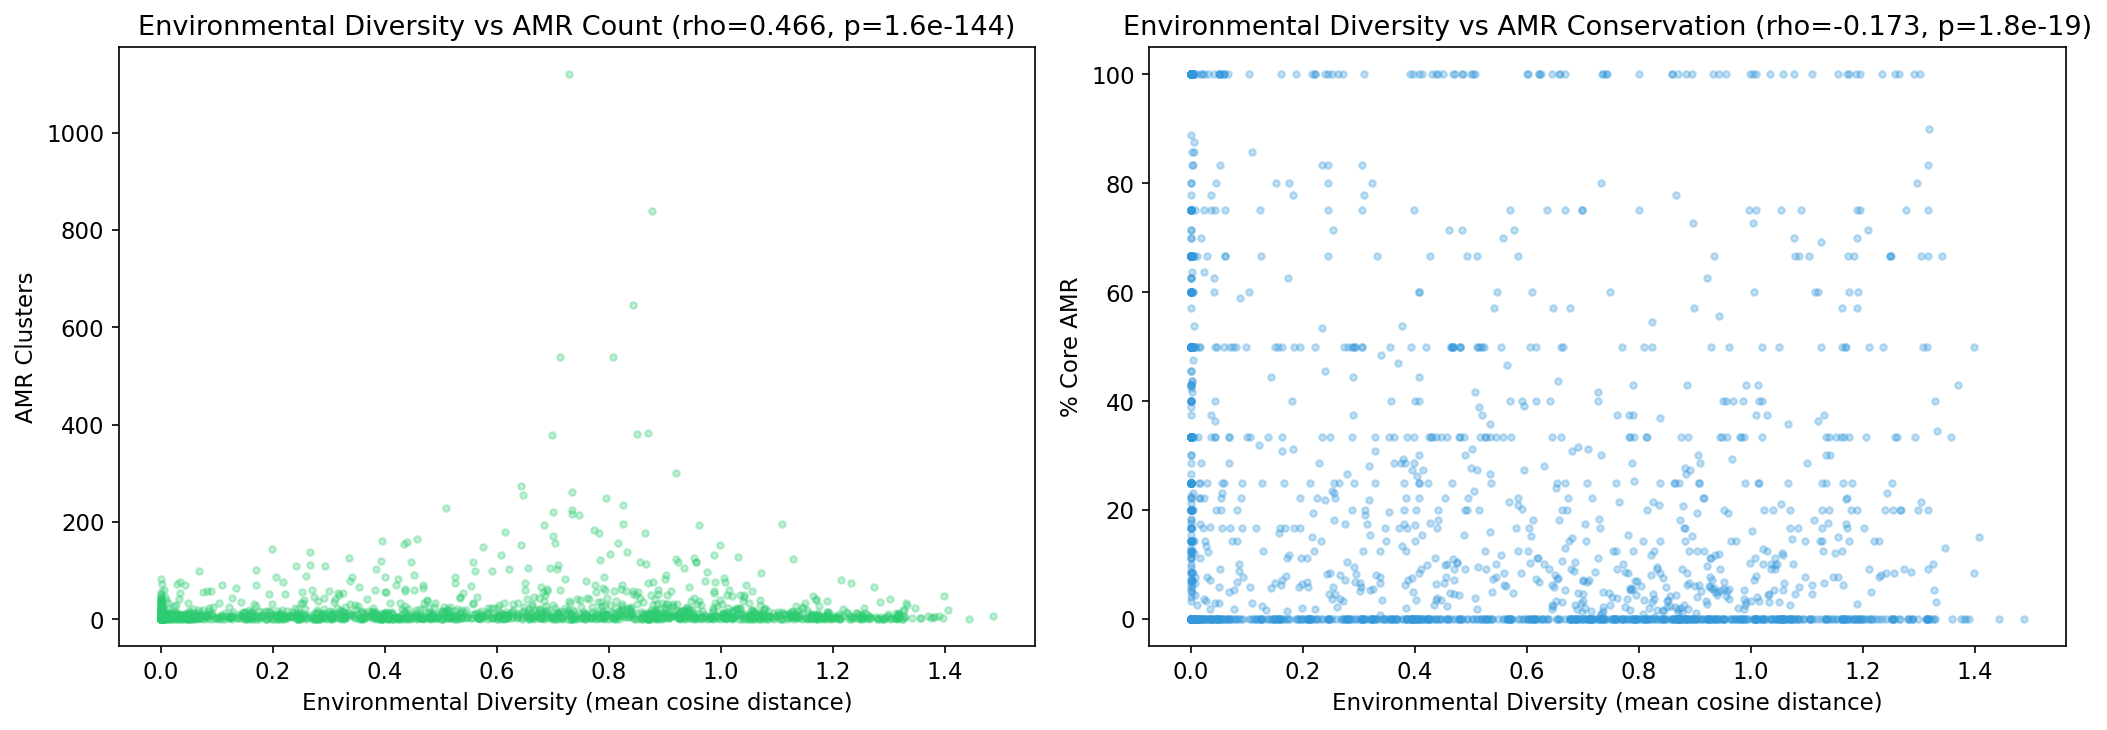

In [6]:
# Per-species environmental diversity = mean pairwise cosine distance of embeddings
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import normalize

# Compute per-species embedding spread (std of L2-normed embeddings)
species_ae = ae.groupby('gtdb_species_clade_id').filter(lambda x: len(x) >= 3)
species_with_emb = species_ae['gtdb_species_clade_id'].unique()
print(f"Species with >= 3 genomes and embeddings: {len(species_with_emb):,}")

env_diversity = []
for sp in species_with_emb:
    sp_embs = ae[ae['gtdb_species_clade_id'] == sp][emb_cols].values.astype(float)
    if len(sp_embs) >= 3 and not np.isnan(sp_embs).all():
        sp_embs = sp_embs[~np.isnan(sp_embs).any(axis=1)]
        if len(sp_embs) >= 3:
            normed = normalize(sp_embs, norm='l2')
            dists = pdist(normed, metric='cosine')
            env_diversity.append({
                'gtdb_species_clade_id': sp,
                'mean_cosine_dist': np.mean(dists),
                'n_genomes_with_emb': len(sp_embs)
            })

env_div = pd.DataFrame(env_diversity)
print(f"Species with environmental diversity scores: {len(env_div):,}")

# Merge with AMR species data
env_div_amr = env_div.merge(species, on='gtdb_species_clade_id', how='inner')
print(f"AMR species with environmental diversity: {len(env_div_amr):,}")

# Correlation: environmental diversity vs AMR count
from scipy.stats import spearmanr
rho, p = spearmanr(env_div_amr['mean_cosine_dist'], env_div_amr['n_amr'])
print(f"\nSpearman correlation (env diversity vs AMR count): rho={rho:.3f}, p={p:.2e}")

# Correlation: env diversity vs % core AMR
rho2, p2 = spearmanr(env_div_amr['mean_cosine_dist'], env_div_amr['pct_core_amr'])
print(f"Spearman correlation (env diversity vs % core AMR): rho={rho2:.3f}, p={p2:.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(env_div_amr['mean_cosine_dist'], env_div_amr['n_amr'],
                alpha=0.3, s=10, color='#2ecc71')
axes[0].set_xlabel('Environmental Diversity (mean cosine distance)')
axes[0].set_ylabel('AMR Clusters')
axes[0].set_title(f'Environmental Diversity vs AMR Count (rho={rho:.3f}, p={p:.1e})')

axes[1].scatter(env_div_amr['mean_cosine_dist'], env_div_amr['pct_core_amr'],
                alpha=0.3, s=10, color='#3498db')
axes[1].set_xlabel('Environmental Diversity (mean cosine distance)')
axes[1].set_ylabel('% Core AMR')
axes[1].set_title(f'Environmental Diversity vs AMR Conservation (rho={rho2:.3f}, p={p2:.1e})')

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_alphaearth_diversity.png')
plt.show()